# Phase 2: Baseline XGBoost & SHAP Reference

This notebook:
1. Executes the baseline training script `scripts/train_baseline.py` (which trains models across all 5 seeds).
2. Computes the summary statistics (`Mean ± Std`) for baseline classification metrics (ROC-AUC, F1, Precision, Recall) across all seeds for both datasets.
3. Renders the SHAP beeswarm and bar charts for visual review.

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as display

## 1. Run Baseline Pipeline

We execute `train_baseline.py` to fit the baseline models, log test set performance, and extract SHAP attribution references.

In [2]:
# Execute train_baseline script if not already run
# Note: We add a conditional check so we don't rerun it unnecessarily if files already exist
import subprocess
german_summary = "../../results/baseline/german_credit_real_xgboost_summary.json"
if not os.path.exists(german_summary):
    print("Running baseline training script...")
    subprocess.run([sys.executable, "../../scripts/train_baseline.py"], check=True)
else:
    print("Baseline summary file already exists. Skipping script execution (using cached results).")

Baseline summary file already exists. Skipping script execution (using cached results).


## 2. Compile and Summarize Performance Statistics (Mean ± Std)

We load the saved summary JSON files to inspect classification metrics across seeds and aggregate performance.

In [3]:
def compile_summary(summary_path):
    with open(summary_path, 'r') as f:
        summary = json.load(f)
        
    dataset = summary["dataset"]
    best_params = summary["best_parameters"]
    runs = summary["runs"]
    
    print(f"=== {dataset.upper()} BASELINE SUMMARY ===")
    print(f"Optimal Hyperparameters: {best_params}\n")
    
    run_records = []
    for r in runs:
        run_records.append({
            "Seed": r["seed"],
            "ROC-AUC": r["roc_auc"],
            "F1-Score": r["f1"],
            "Precision": r["precision"],
            "Recall": r["recall"]
        })
        
    df = pd.DataFrame(run_records)
    
    # Calculate stats
    stats = []
    for m in ["ROC-AUC", "F1-Score", "Precision", "Recall"]:
        mean_val = df[m].mean()
        std_val = df[m].std()
        stats.append({
            "Metric": m,
            "Mean": f"{mean_val:.4f}",
            "Std": f"{std_val:.4f}",
            "Mean ± Std": f"{mean_val:.4f} ± {std_val:.4f}"
        })
    df_stats = pd.DataFrame(stats)
    
    print("Individual Runs:")
    display.display(df)
    print("\nAggregated Performance Summary:")
    display.display(df_stats)
    print("\n" + "="*50 + "\n")

# Load and show German Credit stats
german_summary_path = "../../results/baseline/german_credit_real_xgboost_summary.json"
if os.path.exists(german_summary_path):
    compile_summary(german_summary_path)
else:
    print("German Credit baseline summary file is missing.")

=== GERMAN_CREDIT BASELINE SUMMARY ===
Optimal Hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

Individual Runs:


,Seed,ROC-AUC,F1-Score,Precision,Recall
0,42,0.752540,0.561224,0.518868,0.611111
1,123,0.756931,0.563107,0.500000,0.644444
2,456,0.765132,0.584615,0.542857,0.633333
3,789,0.785608,0.586538,0.516949,0.677778
4,1337,0.797302,0.617021,0.591837,0.644444



Aggregated Performance Summary:


,Metric,Mean,Std,Mean ± Std
0,ROC-AUC,0.7715,0.0192,0.7715 ± 0.0192
1,F1-Score,0.5825,0.0226,0.5825 ± 0.0226
2,Precision,0.5341,0.0357,0.5341 ± 0.0357
3,Recall,0.6422,0.0241,0.6422 ± 0.0241


In [4]:
# Load and show GMSC stats
gmsc_summary_path = "../../results/baseline/gmsc_real_xgboost_summary.json"
if os.path.exists(gmsc_summary_path):
    compile_summary(gmsc_summary_path)
else:
    print("GMSC baseline summary file is missing.")

=== GMSC BASELINE SUMMARY ===
Optimal Hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}

Individual Runs:


,Seed,ROC-AUC,F1-Score,Precision,Recall
0,42,0.805258,0.290832,0.184246,0.690
1,123,0.854889,0.333679,0.210458,0.805
2,456,0.850890,0.319126,0.204196,0.730
3,789,0.834806,0.305155,0.192208,0.740
4,1337,0.835198,0.303719,0.191406,0.735



Aggregated Performance Summary:


,Metric,Mean,Std,Mean ± Std
0,ROC-AUC,0.8362,0.0195,0.8362 ± 0.0195
1,F1-Score,0.3105,0.0164,0.3105 ± 0.0164
2,Precision,0.1965,0.0106,0.1965 ± 0.0106
3,Recall,0.7400,0.0414,0.7400 ± 0.0414


## 3. Render Reference SHAP Plots

We display the generated SHAP beeswarm and bar charts for visual inspection of feature attributions for the first seed (42).

=== German Credit SHAP Beeswarm (Seed 42) ===


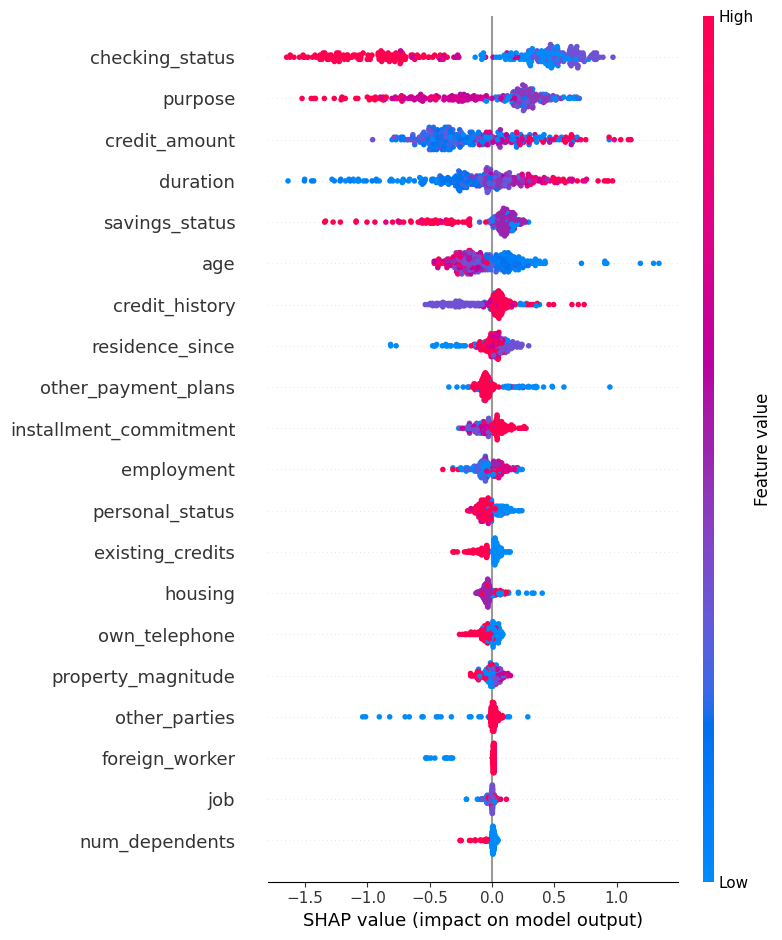


=== German Credit SHAP Feature Importance Bar (Seed 42) ===


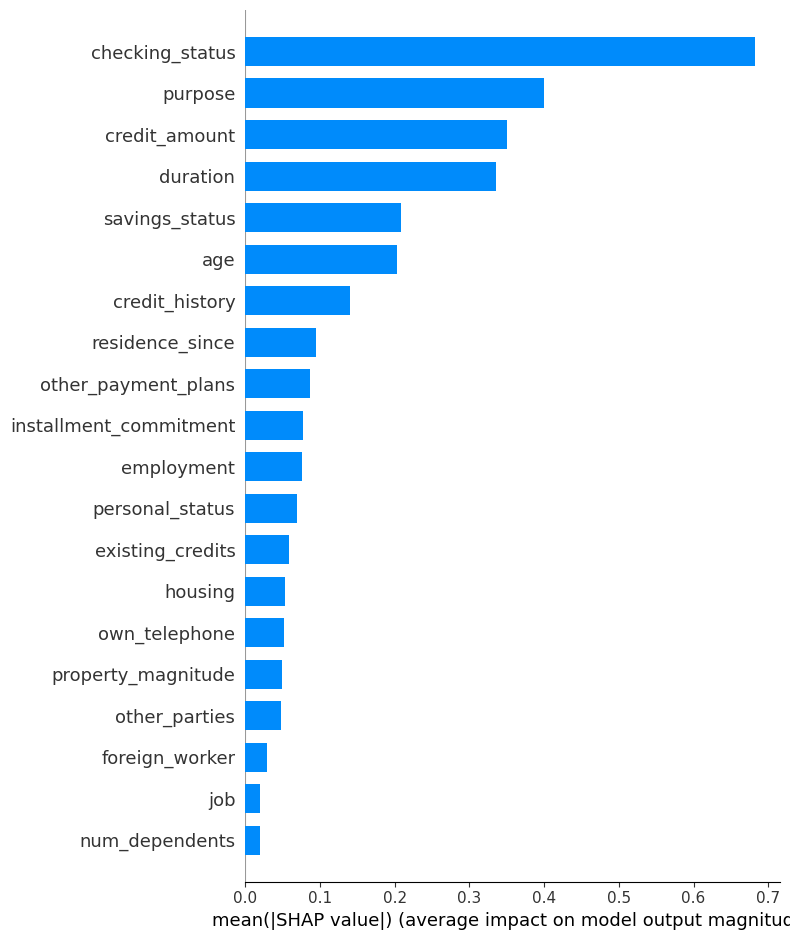

In [5]:
# Display German Credit SHAP Plots (Seed 42)
beeswarm_g = "../../figures/shap/german_credit_real_xgboost_seed42_v1_shap_beeswarm.png"
bar_g = "../../figures/shap/german_credit_real_xgboost_seed42_v1_shap_bar.png"

if os.path.exists(beeswarm_g):
    print("=== German Credit SHAP Beeswarm (Seed 42) ===")
    display.display(display.Image(filename=beeswarm_g))
if os.path.exists(bar_g):
    print("\n=== German Credit SHAP Feature Importance Bar (Seed 42) ===")
    display.display(display.Image(filename=bar_g))

=== GMSC SHAP Beeswarm (Seed 42) ===


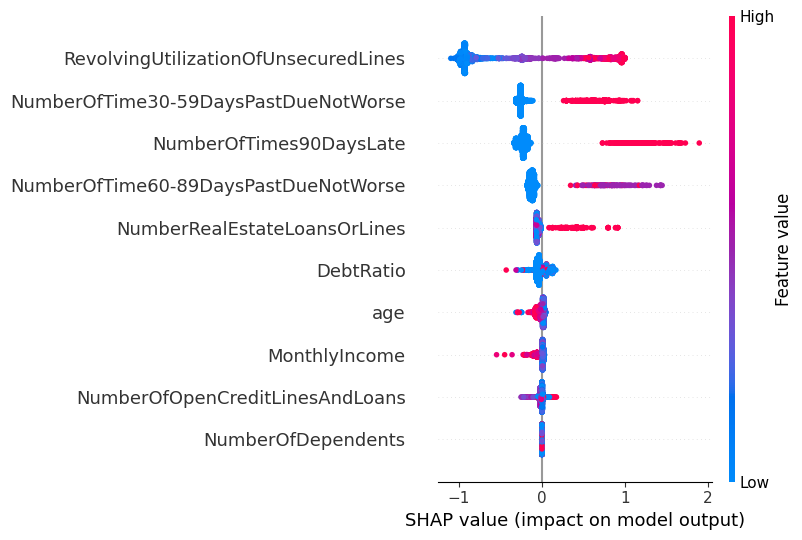


=== GMSC SHAP Feature Importance Bar (Seed 42) ===


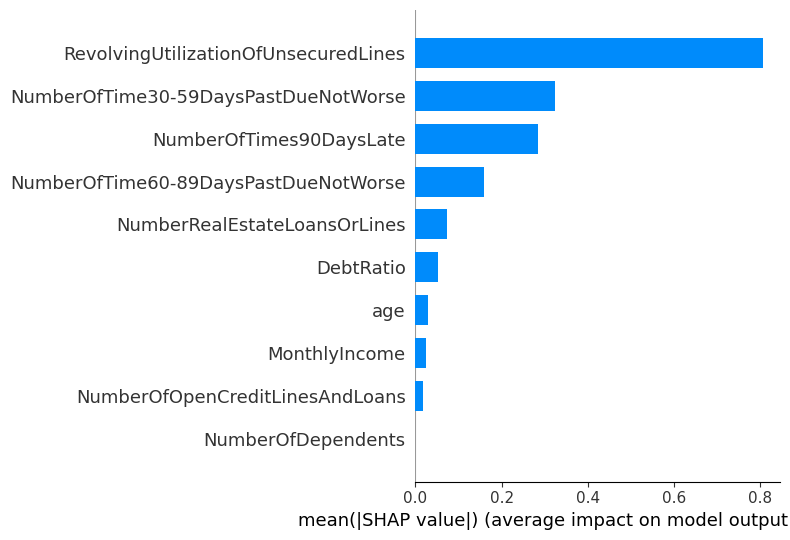

In [6]:
# Display GMSC SHAP Plots (Seed 42)
beeswarm_m = "../../figures/shap/gmsc_real_xgboost_seed42_v1_shap_beeswarm.png"
bar_m = "../../figures/shap/gmsc_real_xgboost_seed42_v1_shap_bar.png"

if os.path.exists(beeswarm_m):
    print("=== GMSC SHAP Beeswarm (Seed 42) ===")
    display.display(display.Image(filename=beeswarm_m))
if os.path.exists(bar_m):
    print("\n=== GMSC SHAP Feature Importance Bar (Seed 42) ===")
    display.display(display.Image(filename=bar_m))